In [2]:
# 09 - Model Comparison

#Rol 4: Model Comparator
#Sprint 3 - Comparación de modelos baseline

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = {
    "Modelo": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Accuracy_mean": [0.8930, 0.8693, 0.9061, 0.9024, 0.8938],
    "Accuracy_std":  [0.0081, 0.0080, 0.0109, 0.0095, 0.0104],
    "F1_mean":       [0.5108, 0.5487, 0.6294, 0.5937, 0.5410],
    "F1_std":        [0.0379, 0.0203, 0.0436, 0.0363, 0.0433],
    "Precision_mean":[0.7492, 0.5470, 0.7299, 0.7437, 0.7184],
    "Precision_std": [0.0572, 0.0295, 0.0504, 0.0574, 0.0635],
    "Recall_mean":   [0.3877, 0.5507, 0.5533, 0.4943, 0.4345],
    "Recall_std":    [0.0297, 0.0121, 0.0386, 0.0257, 0.0360],
    "ROC_AUC_mean":  [0.8937, 0.7368, 0.9179, 0.8629, 0.8046],
    "ROC_AUC_std":   [0.0141, 0.0094, 0.0138, 0.0207, 0.0152]
}

df = pd.DataFrame(data)
df

,Modelo,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,ROC_AUC_mean,ROC_AUC_std
0,Logistic Regression,0.8930,0.0081,0.5108,0.0379,0.7492,0.0572,0.3877,0.0297,0.8937,0.0141
1,Decision Tree,0.8693,0.0080,0.5487,0.0203,0.5470,0.0295,0.5507,0.0121,0.7368,0.0094
2,Random Forest,0.9061,0.0109,0.6294,0.0436,0.7299,0.0504,0.5533,0.0386,0.9179,0.0138
3,SVM,0.9024,0.0095,0.5937,0.0363,0.7437,0.0574,0.4943,0.0257,0.8629,0.0207
4,KNN,0.8938,0.0104,0.5410,0.0433,0.7184,0.0635,0.4345,0.0360,0.8046,0.0152


In [5]:
ranking_f1 = df.sort_values(by="F1_mean", ascending=False)
ranking_f1[["Modelo", "F1_mean", "Precision_mean", "Recall_mean", "ROC_AUC_mean"]]

,Modelo,F1_mean,Precision_mean,Recall_mean,ROC_AUC_mean
2,Random Forest,0.6294,0.7299,0.5533,0.9179
3,SVM,0.5937,0.7437,0.4943,0.8629
1,Decision Tree,0.5487,0.5470,0.5507,0.7368
4,KNN,0.5410,0.7184,0.4345,0.8046
0,Logistic Regression,0.5108,0.7492,0.3877,0.8937


In [6]:
top_3 = ranking_f1.head(3)
top_3[["Modelo", "F1_mean", "ROC_AUC_mean", "Precision_mean", "Recall_mean"]]

,Modelo,F1_mean,ROC_AUC_mean,Precision_mean,Recall_mean
2,Random Forest,0.6294,0.9179,0.7299,0.5533
3,SVM,0.5937,0.8629,0.7437,0.4943
1,Decision Tree,0.5487,0.7368,0.5470,0.5507


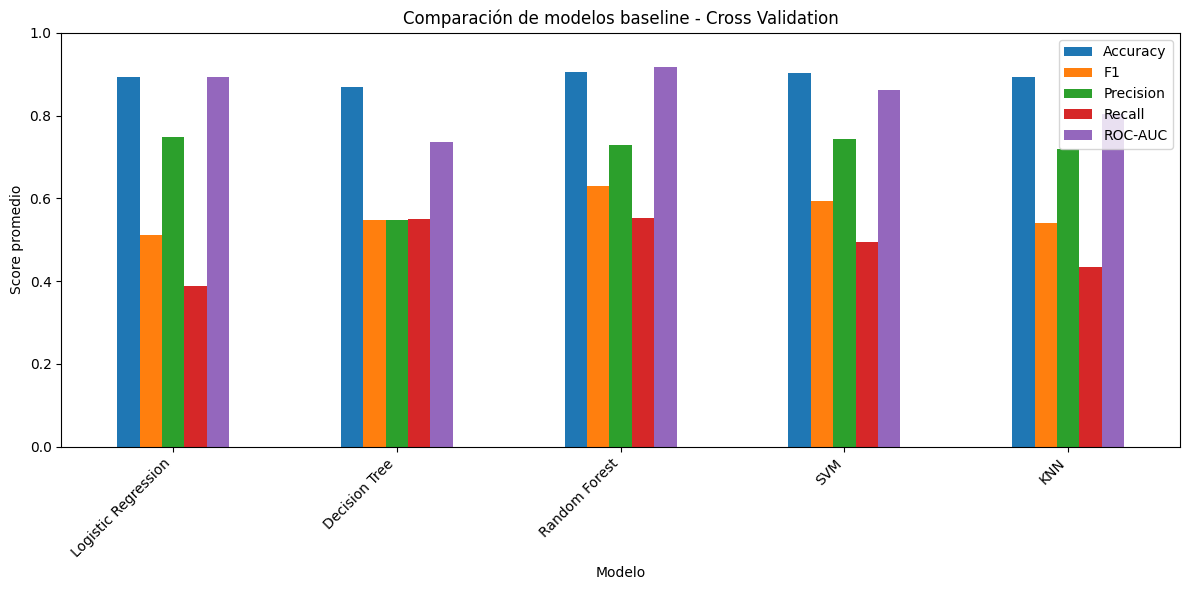

In [7]:
metrics = ["Accuracy_mean", "F1_mean", "Precision_mean", "Recall_mean", "ROC_AUC_mean"]

df_plot = df.set_index("Modelo")[metrics]

ax = df_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Comparación de modelos baseline - Cross Validation")
plt.ylabel("Score promedio")
plt.xlabel("Modelo")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(["Accuracy", "F1", "Precision", "Recall", "ROC-AUC"])
plt.tight_layout()
plt.show()

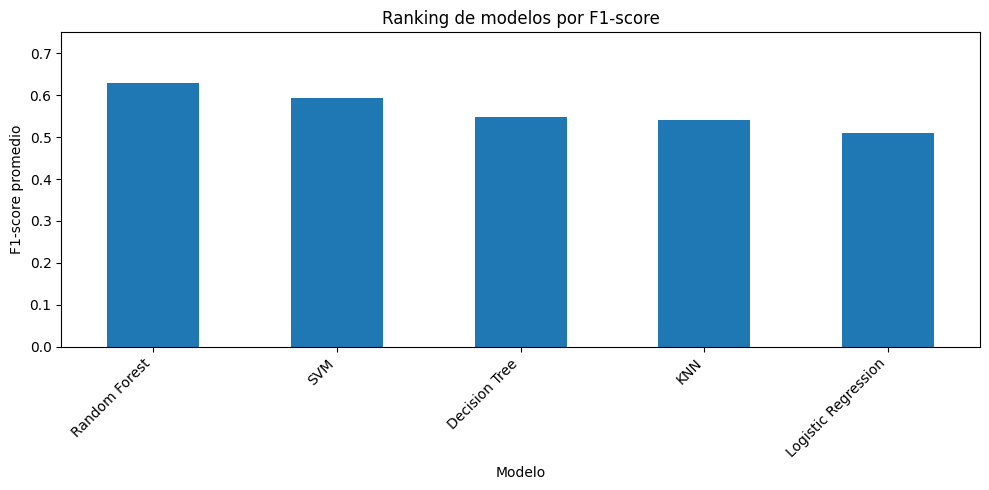

In [8]:
ranking_f1.set_index("Modelo")["F1_mean"].plot(kind="bar", figsize=(10, 5))

plt.title("Ranking de modelos por F1-score")
plt.ylabel("F1-score promedio")
plt.xlabel("Modelo")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 0.75)
plt.tight_layout()
plt.show()

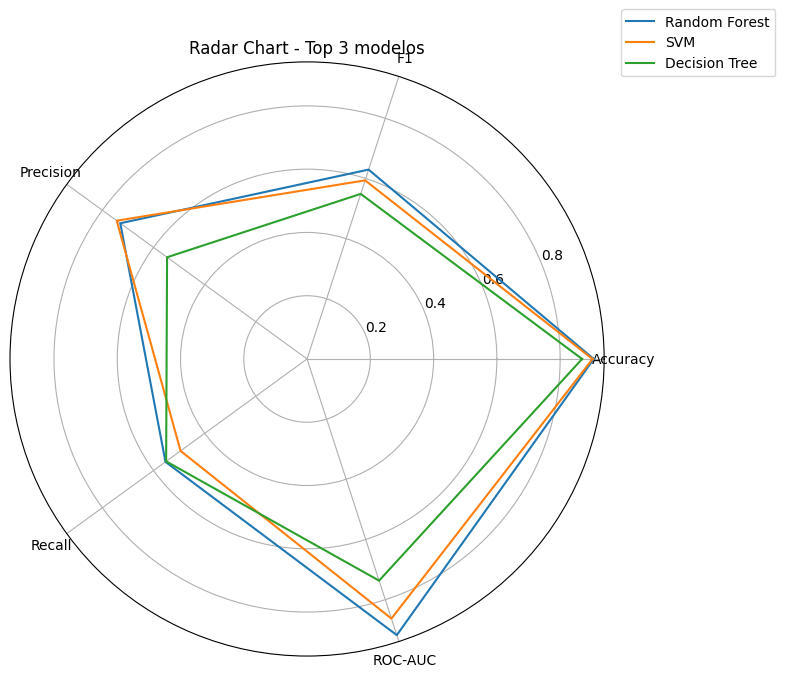

In [9]:
radar_metrics = ["Accuracy_mean", "F1_mean", "Precision_mean", "Recall_mean", "ROC_AUC_mean"]
labels = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC"]

models_to_plot = ["Random Forest", "SVM", "Decision Tree"]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(8, 8))

for model in models_to_plot:
    values = df[df["Modelo"] == model][radar_metrics].values.flatten()
    values = np.concatenate((values, [values[0]]))
    plt.polar(angles, values, label=model)

plt.xticks(angles[:-1], labels)
plt.title("Radar Chart - Top 3 modelos")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [10]:
## Análisis de trade-offs

Se observa que todos los modelos tienen una accuracy alta, cercana a 0.90. Sin embargo, debido al desbalance del dataset, la accuracy no debe ser la métrica principal. Por ello, se prioriza el F1-score, ya que permite evaluar mejor el balance entre precision y recall.

### Precision vs Recall

- Logistic Regression tiene buena precision, pero recall muy bajo. Esto significa que cuando predice Revenue suele acertar, pero deja pasar muchos casos positivos.
- Decision Tree tiene el mejor recall junto con Random Forest, pero su precision y ROC-AUC son más bajos.
- Random Forest obtiene el mejor F1-score y el mejor ROC-AUC, por lo que presenta el mejor balance general.
- SVM tiene buen F1-score y alta precision, aunque su recall es menor que Random Forest y Decision Tree.
- KNN tiene desempeño medio-bajo y no destaca en ninguna métrica principal.

### Velocidad de entrenamiento

- Más rápidos: Logistic Regression y Decision Tree.
- Intermedios: KNN y SVM.
- Más costoso: Random Forest, debido a que entrena varios árboles.

### Interpretabilidad

- Más interpretables: Logistic Regression y Decision Tree.
- Interpretabilidad media: Random Forest.
- Menos interpretables: SVM y KNN.

SyntaxError: invalid syntax (1677984077.py, line 3)

In [ ]:
## Selección de modelos para Sprint 4

Se seleccionan los siguientes modelos para tuning en el Sprint 4:

1. Random Forest
2. SVM
3. Decision Tree

Random Forest es el mejor candidato porque obtiene el mayor F1-score y el mayor ROC-AUC. SVM se selecciona por su buen rendimiento general y alta precision. Decision Tree se incluye porque tiene buen recall y es fácil de interpretar.

## Modelos descartados

- Logistic Regression: se descarta porque tiene el recall más bajo, lo que indica que no detecta adecuadamente la clase positiva Revenue.
- KNN: se descarta porque presenta menor F1-score y menor ROC-AUC que los modelos seleccionados, además de no destacar en interpretabilidad ni rendimiento.

In [ ]:
## Conclusión

El modelo con mejor desempeño general fue Random Forest, seguido por SVM y Decision Tree. Estos tres modelos serán considerados para el Sprint 4, donde se realizará tuning de hiperparámetros.

Logistic Regression y KNN fueron descartados debido a su menor capacidad para detectar correctamente la clase positiva y su menor rendimiento comparativo en F1-score.